
===== METRICS =====
Total Failed Attempts: 144
Total Anomalies: 8
Attack Campaign Points: 1


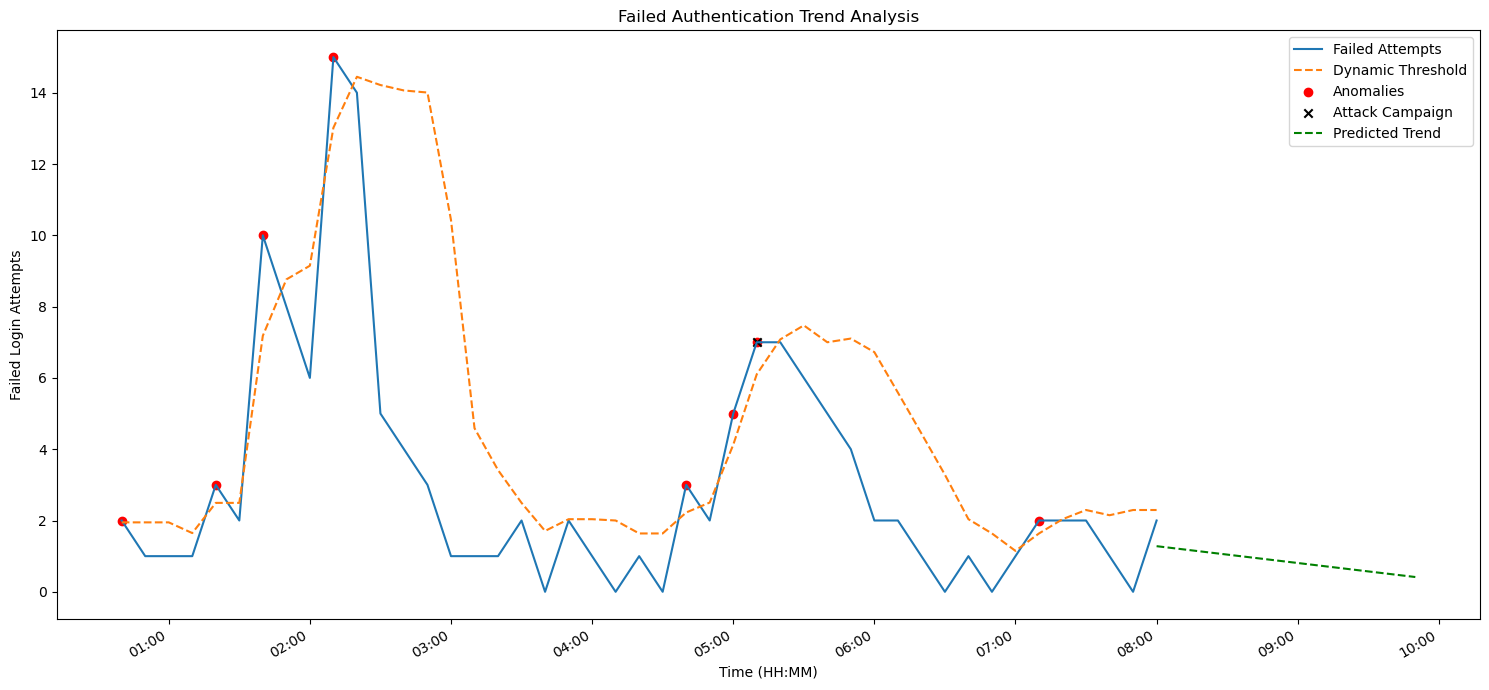

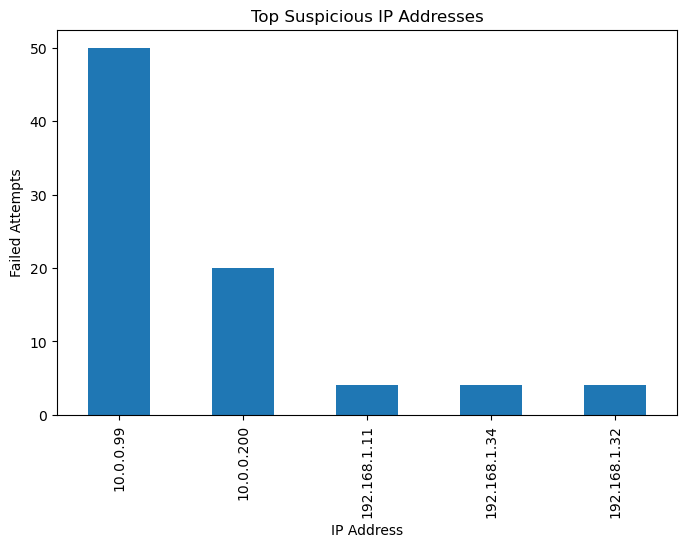

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.dates as mdates

# -------------------------------
# STEP 1: Load Dataset
# -------------------------------
df = pd.read_csv("real_auth_logs.csv")   # change filename if needed

# -------------------------------
# STEP 2: Preprocessing
# -------------------------------
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])

df['status'] = df['status'].str.upper().str.strip()

# -------------------------------
# STEP 3: Filter Failed Logins
# -------------------------------
fail_df = df[df['status'] == 'FAIL'].copy()
fail_df.set_index('timestamp', inplace=True)

# -------------------------------
# STEP 4: Time-Series Aggregation (10 min)
# -------------------------------
time_series = fail_df.resample('10min').size()

data = pd.DataFrame(time_series, columns=['failures'])
data['failures'] = data['failures'].fillna(0)

# -------------------------------
# STEP 5: Dynamic Threshold
# -------------------------------
window_size = 5

data['rolling_mean'] = data['failures'].rolling(window=window_size).mean()
data['rolling_std'] = data['failures'].rolling(window=window_size).std()

data['threshold'] = data['rolling_mean'] + (1 * data['rolling_std'])

data = data.dropna()

# -------------------------------
# STEP 6: Anomaly Detection
# -------------------------------
data['anomaly'] = data['failures'] > data['threshold']

# -------------------------------
# STEP 7: Attack Campaign Detection
# -------------------------------
data['attack_campaign'] = data['anomaly'].rolling(window=2).sum() >= 2

# -------------------------------
# STEP 8: Prediction (Fixed)
# -------------------------------
data['time_index'] = np.arange(len(data))

X = data[['time_index']]
y = data['failures']

model = LinearRegression()
model.fit(X, y)

# Proper DataFrame input (no warning)
future_index = pd.DataFrame({
    'time_index': np.arange(len(data), len(data)+12)
})

predictions = model.predict(future_index)

# Avoid negative predictions
predictions = np.maximum(predictions, 0)

future_time = pd.date_range(start=data.index[-1], periods=12, freq='10min')

# -------------------------------
# STEP 9: Metrics
# -------------------------------
print("\n===== METRICS =====")
print("Total Failed Attempts:", len(fail_df))
print("Total Anomalies:", data['anomaly'].sum())
print("Attack Campaign Points:", data['attack_campaign'].sum())

# -------------------------------
# STEP 10: Visualization
# -------------------------------
plt.figure(figsize=(15,7))

plt.plot(data.index, data['failures'], label='Failed Attempts')
plt.plot(data.index, data['threshold'], linestyle='--', label='Dynamic Threshold')

plt.scatter(data[data['anomaly']].index,
            data[data['anomaly']]['failures'],
            color='red', label='Anomalies')

plt.scatter(data[data['attack_campaign']].index,
            data[data['attack_campaign']]['failures'],
            marker='x', color='black', label='Attack Campaign')

plt.plot(future_time, predictions, linestyle='--', color='green', label='Predicted Trend')

# Clean X-axis format
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()

plt.xlabel("Time (HH:MM)")
plt.ylabel("Failed Login Attempts")
plt.title("Failed Authentication Trend Analysis")

plt.legend()
plt.tight_layout()
plt.show()

#suspicious IP
top_ips = fail_df['ip'].value_counts().head(5)

plt.figure(figsize=(8,5))

top_ips.plot(kind='bar')

plt.xlabel("IP Address")
plt.ylabel("Failed Attempts")
plt.title("Top Suspicious IP Addresses")

plt.show()
